# Проект №3. Рынок заведений общественного питания Москвы

<br> **Выполнил:** Золина Полина Владимировна
<br> **Специальность:** Дата-аналитик: старт карьеры
<br> **Группа:** 801

<a id=content></a>
### Содержание

<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Обработка пропусков](#2.1.)
    <br>[2.2. Обработка дубликатов](#2.2.)
    <br>[2.3. Преобразование типов данных](#2.3.)
    <br>[2.4. Обработка аномальных значений](#2.4.)
3. [<b>Разведочный анализ данных</b>](#3)
    <br>[3.1. Исследовать соотношение типов объектов общественного питания по количеству. Построить график](#3.1.)
    <br>[3.2. Исследовать соотношение сетевых и несетевых объектов общественного питания по количеству. Построить график](#3.2.)
    <br>[3.3. Установить для какого типа объекта общественного питания характерно сетевое распространение](#3.3.)
    <br>[3.4. Что характерно для сетевых заведений: много заведений с небольшим числом мест в каждом или мало заведений с большим количеством посадочных мест?](#3.4.)
    <br>[3.5. Для каждого типа объекта общественного питания найти среднее количество посадочных мест. Какой тип представляет в среднем самое большое количество посадочных мест? Построить график](#3.5.)
    <br>[3.6. Выделить в отдельный столбец информацию об улице из столбца `adress`](#3.6.)
    <br>[3.7. Построить график топ-10 улиц по количеству объектов общественного питания](#3.7.)
    <br>[3.8. Найти число улиц с одним объектом общественного питания](#3.8.)
    <br>[3.9. Рассмотреть распределение количества посадочных мест для улиц с большим количеством объектов общественного питания. Какие закономерности можно выявить?](#3.9.)
4. [<b>Проверка гипотез о равенстве количества посадочных мест в заведениях сетевого и несетевого типа</b>](#4)
5. [<b>Рекомендации по открытию нового объекта общественного питания</b>](#5)
    <br>[5.1. Тип объекта общественного питания](#5.1.)
    <br>[5.2. Количество посадочных мест](#5.2.)
    <br>[5.3. Место расположения](#5.3.)
    <br>[5.4. Проведение дополнительных исследований](#5.4.)
    <br>[5.5. Выводы по рекомендациям](#5.5.)

<a id=descr_proj></a>
**Цель проекта:** по открытым данным о заведениях общественного питания в Москве требуется провести исследование рынка.

<a id=1></a>
## Описание данных

Данные о заведениях общественного питания Москвы представлены по 15 366 строкам в разрезе 6 столбцов со следующими характерными признаками:

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|:--------------------|:----------------|:--|:-----------------------|
|1.|`id`|идентификатор объекта| 15366 уникальных идентификационных номеров объекта общественного питания |от 838 до 223439|
|2.|`object_name`|название объекта общественного питания| 10393 уникальных наименований объектов общественного питания|от `1-ЫЙ МОСКОВСКИЙ КАДЕТСКИЙ КОРПУС` до `школа 476`|
|3.|`chain`|сетевой объект| булев признак принадлежности объекта общественного питания к сетевому типу| нет / да|
|4.|`object_type`|тип объекта общественного питания|9 уникальных типов ООП| `кафе`, `столовая`, `закусочная`, `предприятие быстрого обслуживания`, `ресторан`, `кафетерий`, `буфет`, `бар`, `магазин (отдел кулинарии)`|
|5.|`address`|адрес| 9108 уникальных адресов расположения объекта общественного питания| от `1-й Нагатинский проезд, дом 10` до `улица Сергея Макеева, дом 9, строение 2`|
|6.|`number`|количество посадочных мест|315 уникальных значений числа посадочных мест в заведении общественного питания |от 0 до 1700|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датафрейму.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

from scipy import stats
from  scipy.stats import ttest_ind

import warnings
warnings.simplefilter("ignore")

# сохранение графиков
%matplotlib inline

# графики в svg выглядят более чёткими
%config InlineBackend.figure_format = 'svg'

# увеличим исходный размер графиков и установим отображение сетки по умолчанию
from pylab import rcParams
rcParams["figure.figsize"] = 10, 6
sns.set_style("whitegrid", {'axes.grid' : True})

In [2]:
# загрузка датасета
df = pd.read_csv('tgu_internship_project3.csv', sep=',')
df.head()

,id,object_name,chain,object_type,address,number
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35
2,24309,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95
3,21894,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40
4,119365,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50


In [3]:
# общая информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15366 entries, 0 to 15365
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15366 non-null  int64 
 1   object_name  15366 non-null  object
 2   chain        15366 non-null  object
 3   object_type  15366 non-null  object
 4   address      15366 non-null  object
 5   number       15366 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 720.4+ KB


<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1.></a>
### Шаг 2.1. Обработка пропусков

In [4]:
# очистка данных: обработка пропусков
df.isnull().sum()

id             0
object_name    0
chain          0
object_type    0
address        0
number         0
dtype: int64

Пропущенных значений в данных нет.

<a id=2.2.></a>
### Шаг 2.2. Обработка дубликатов

In [5]:
# очистка данных: удаление дубликатов по всем полям, кроме id
df = df.drop_duplicates(subset=['object_name', 'chain', 'object_type', 'address', 'number'], keep='first')
df.shape

(15284, 6)

<a id=2.3.></a>
### Шаг 2.3. Преобразование типов данных

In [6]:
# очистка данных: преобразование данных
df = df.replace({'chain' : {'да':True, 'нет':False}})

In [7]:
# проверка результатов преобразования
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15284 entries, 0 to 15365
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15284 non-null  int64 
 1   object_name  15284 non-null  object
 2   chain        15284 non-null  bool  
 3   object_type  15284 non-null  object
 4   address      15284 non-null  object
 5   number       15284 non-null  int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 731.4+ KB


**Выводы:** в столбце `chain` была выполнена замена значений со строковых `object` на логические `True` / `False`.

<a id=2.4.></a>
### Шаг 2.4. Обработка аномальных значений

В ходе описательного анализа поступивших в работу данных мы можем отметить аномальные значения в столбце `number`, содержащим сведения о количестве посадочных мест. Здесь значения варьируются от 0 до 1700. Проверим значения количества посадочных мест по каждому типу объекта общественного питания: кафе, столовая, закусочная, предприятие быстрого обслуживания, ресторан, кафетерий, буфет, бар, магазин (отдел кулинарии). Для этого построим соответсвующую диаграмму размаха.

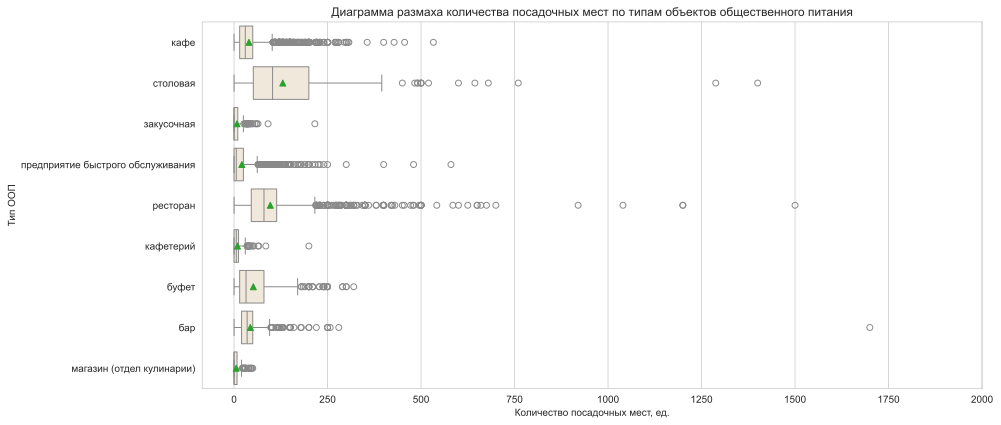

In [8]:
# создадим ящик с усами по количеству посадочных мест в соответствии с типам объекта общественного питания
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=df, y='object_type', x='number', showmeans=True, color='#F3E9D7')
ax.set(xlabel='Количество посадочных мест, ед.', ylabel='Тип ООП', title='Диаграмма размаха количества посадочных мест по типам объектов общественного питания')
ax.set_xlim(right=2000)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# очистка данных: минимальные (нулевые) значения по количеству посадочных мест
total_zero = df.query('number == 0')['number'].count()
total_records = len(df)
percentage = (total_zero / total_records) * 100

print(f'Всего в массиве данных присутствует {total_zero} нулевых значений по количеству посадочных мест '
      f'по всем типам объектов общественного питания. Это составляет {percentage:.1f}% от всех записей. '
      f'Найдём количество нулевых значений по посадочным местам для каждого типа ООП соответственно, '
      f'обратимся к действующим нормам законодательства в данной области, и после этого примем решение '
      f'о сохранении валидных данных.')

print('Нулевые значения количества посадочных мест:')

# получаем список уникальных типов объектов, у которых есть нулевые значения в 'number'
object_types = df[df['number'] == 0]['object_type'].unique()

for obj_type in object_types:
    count = ((df['number'] == 0) & (df['object_type'] == obj_type)).sum()
    print(f'в {obj_type} - {count}')

Всего в массиве данных присутствует 1589 нулевых значений по количеству посадочных мест по всем типам объектов общественного питания. Это составляет 10.4% от всех записей. Найдём количество нулевых значений по посадочным местам для каждого типа ООП соответственно, обратимся к действующим нормам законодательства в данной области, и после этого примем решение о сохранении валидных данных.
Нулевые значения количества посадочных мест:
в закусочная - 182
в предприятие быстрого обслуживания - 690
в столовая - 19
в кафетерий - 111
в кафе - 306
в магазин (отдел кулинарии) - 145
в буфет - 64
в бар - 28
в ресторан - 44


In [10]:
# очистка данных: работа с аномальными значениями количества посадочных мест
# все строки столбца `number`, где число посадочных мест равно нулю, заполняем средним значением
mean_by_type = df[df['number'] > 0].groupby('object_type')['number'].mean().round().astype(int)
df.loc[df['number'] == 0, 'number'] = df.loc[df['number'] == 0, 'object_type'].map(mean_by_type)

In [11]:
# очистка данных: работа с выбросами по количеству посадочных мест
# максимальные значения количества посадочных мест по каждому типу ООП
type_list_max = df.groupby(by='object_type').agg({'number':'max'}).sort_values(by='number', ascending=False).round().reset_index()
type_list_max

,object_type,number
0,бар,1700
1,ресторан,1500
2,столовая,1400
3,предприятие быстрого обслуживания,580
4,кафе,533
5,буфет,320
6,закусочная,216
7,кафетерий,200
8,магазин (отдел кулинарии),50


In [12]:
# очистка данных: работа с выбросами по количеству посадочных мест
# группа больших значений № 1 - 7 объектов (бар, рестораны, столовые)
max1 = df[(df.number >= 1000) & (df.number <= 1700)].sort_values(by='number', ascending=False).head(50)
max1

,id,object_name,chain,object_type,address,number
12723,199696,Arena by Soho Family,False,бар,"город Москва, Кутузовский проспект, дом 36, ст...",1700
8148,80291,Банкетный зал Шелк,False,ресторан,"город Москва, Большой Саввинский переулок, дом...",1500
8345,27750,СТОЛОВАЯ-БУФЕТ,False,столовая,"город Москва, улица Волхонка, дом 15",1400
9064,19719,КОМБИНАТ ПИТАНИЯ «УПРАВЛЕНИЕ АКАДЕМСЕРВИС»,False,столовая,"город Москва, проспект Вернадского, дом 84, ст...",1288
3686,27026,РУМ СЕРВИС,False,ресторан,"город Москва, площадь Европы, дом 2",1200
4480,27024,РУМ СЕРВИС,False,ресторан,"город Москва, Кутузовский проспект, дом 2/1, с...",1200
2313,26560,Ресторан «АЛЬФА»,False,ресторан,"город Москва, Измайловское шоссе, дом 71, корп...",1040


In [13]:
# очистка данных: работа с выбросами по количеству посадочных мест
# группа больших значений № 2 - 27 объектов (рестораны, столовые, кафе, предприятие быстрого обслуживания)
max2 = df[(df.number >= 500) & (df.number < 1000)].sort_values(by='number', ascending=False).head(50)
max2.head()

,id,object_name,chain,object_type,address,number
9955,171116,EATALY,False,ресторан,"город Москва, Киевская улица, дом 2",920
5649,29232,СТОЛОВАЯ МОСКОВСКИЙ ГУМАНИТАРНЫЙ УНИВЕРСИТЕТ,False,столовая,"город Москва, улица Юности, дом 5, строение 1",760
13299,200905,White Hall,False,ресторан,"город Москва, Ферганская улица, дом 8",700
4110,29320,Столовая,False,столовая,"город Москва, Каширское шоссе, дом 31",680
7280,26269,Ресторан «Шахин Шах»,False,ресторан,"город Москва, улица Маршала Захарова, дом 6, к...",675


In [14]:
# очистка данных: работа с выбросами по количеству посадочных мест
# группа больших значений № 3 - 50 объектов (рестораны, столовые, кафе, предприятие быстрого обслуживания)
max3 = df[(df.number > 300) & (df.number < 500)].sort_values(by='number', ascending=False).head(50)
max3.head()

,id,object_name,chain,object_type,address,number
6441,22856,Ресторан «ЦДТ»,False,ресторан,"город Москва, Ленинский проспект, дом 146",495
12951,195583,Столовая при Сбербанке,False,столовая,"город Москва, улица Вавилова, дом 19",491
12810,194448,Столовая при РГСУ,False,столовая,"город Москва, Лосиноостровская улица, дом 24, ...",490
8526,136421,Столовая на базе ГБОУ Школа №2083. ДО «Семицве...,False,столовая,"город Москва, поселение Рязановское, посёлок З...",483
5112,134338,Пауланер,False,ресторан,"город Москва, Олимпийский проспект, дом 18/1",481


**Вывод:** проведена работа по очистке данных в количественном и качественном направлениях. Были выявлены и удалены 82 дубликата записей.

Проведена оценка разброса данных по одному из ключевых свойств - количество посадочных мест.

Выявлены 1589 строки, где указано нулевое значение количества посадочных мест по всем типам объектов общественного питания. Поскольку эти нулевые данные по объективным причинам являются аномальными и не соответствуют истинному положению дел, для каждого типа объекта общественного было рассчитано среднее количество посадочных мест, которым были заменены нулевые значения в принудительном порядке. Дополнительно следует отметить, что в соответствии с Московскими городскими строииельными нормами 4.14-98 от 1998 года с последующим дополнением и расширением типологии объектов общественного питания на основании ГОСТ Р 50762-2007 и ГОСТ 30389-2013, нижняя граница количества посадочных мест соответствует 25 местам. Выполнение этих требований юридическим лицом или индивидуальным предпринимателем, работающим в сфере общественного питания, повышает вероятность получения группы сертификатов и лицензий, делающих эту деятельность правомерной, а также обеспечивает более чёткое соответствие качества обслуживания уровню (классу) предприятия общественного питания.

Среди максимальных значений можно выделить группу объектов общественного питания, обладающих поистине огромными масштабами площадей, для которых оказание услуг по общественному питанию является только одним из многих направлений деятельности. В соответствии с диаграммой размаха, в первой группе "тяжеловесов" общественного питания (`max1`) находятся площадки массовых мероприятий, трапезная на цокольном этаже Храма Христа Спасителя, академические столовые и рестораны при крупных гостиничных комплексах. На весь массив данных в 15284 записей таких объектов всего 7 единиц. Это значение чрезвычайно мало.

Во второй группе по количеству посадочных мест (`max2`) ожидаемо находятся рестораны, столовые, за единичным исключением кафе и предприятия быстрого обслуживания (2 ед. всего). Здесь количество посадочных мест варьируется от 500 до 1000, и таких объектов всего 27 единиц.

В третьей группе по количеству посадочных мест (`max3`) от 500 до 300 единиц находятся 50 ресторанов, столовых, при этом в эту группу  попадает чуть больше количество кафе и предприятий быстрого обслуживания (6 ед. всего), но говорить о равновесном присутствии на этой нише не приходится.

Таким образом, мы можем принять решение о валидности больших значений количества посадочных мест в столбце `number` и использовать эти данные для дальнейшей работы.

<a id=3></a>
## Шаг 3. Разведочный анализ данных

<a id=3.1.></a>
### 3.1. Исследовать соотношение типов объектов общественного питания по количеству. Построить график.

In [15]:
# сводная таблица с абсолютными и относительными значениями типов ООП
type_list = (
    df['object_type']
    .value_counts()
    .rename_axis('object_type')
    .reset_index(name='count')
    .assign(percentage=lambda x: (x['count'] / x['count'].sum() * 100).round(1))
)

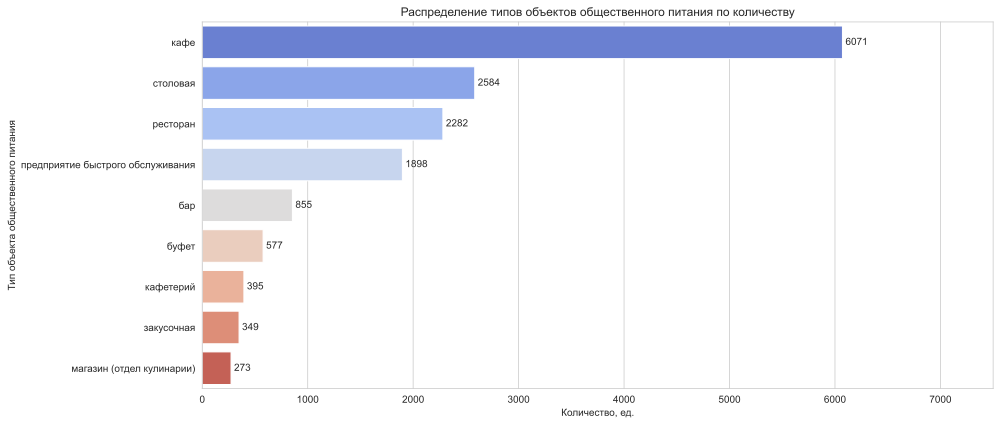

In [16]:
# построение горизонтальной столбчатой диаграммы
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=type_list, x='count', y='object_type', palette='coolwarm')

# метки с количеством на концах столбцов
for container in ax.containers:
    ax.bar_label(container, padding=3)

# вывод графика
plt.title('Распределение типов объектов общественного питания по количеству', fontsize=12)
plt.xlabel('Количество, ед.')
plt.ylabel('Тип объекта общественного питания')
plt.tight_layout()
plt.xlim(right=7500)
plt.show()

**Вывод:** московский рынок объектов общественного питания в соответствии с имеющимися данными можно условно поделить на три крупных сегмента. В первом находится единственный и абсолютный лидер по количеству тип объектов общественного питания - кафе. Их доля достигает 39,7%. Второй равновесный по сумме долей сегмент занимают столовые (16,9%), рестораны (14,9%) и предприятия быстрого обслуживания (12,4%). В третьем сегменте условным лидером можно назвать бары, на них приходитя 5,6%. Остальные типы объектов общественного питания присутствуют примерно в равных долях: буфеты (3,8%), кафетерии (2,6%), закусочные (2,3%) и отделы кулинарии в магазинах (1,8%).

<a id=3.2.></a>
### 3.2. Исследовать соотношение сетевых и несетевых объектов общественного питания по количеству. Построить график.

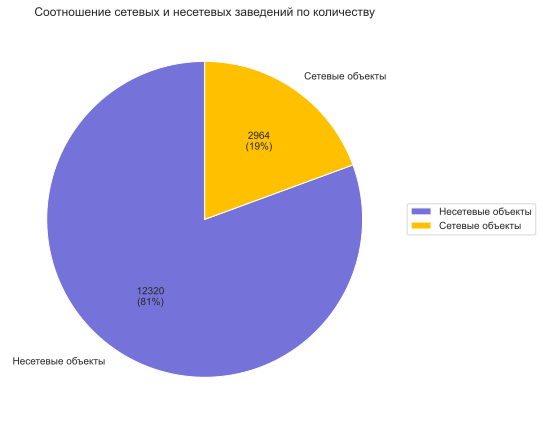

In [17]:
# создаём серию с количеством сетевых и несетевых заведений
chain_counts = df['chain'].value_counts()

# заменяем True/False на понятные метки
chain_counts.index = chain_counts.index.map({True: 'Сетевые объекты', False: 'Несетевые объекты'})

# функция для отображения абсолютного значения и процента
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}\n({pct:.0f}%)'
    return my_autopct

# строим круговую диаграмму
ax = chain_counts.plot.pie(autopct=make_autopct(chain_counts), colors=['#7573D9', '#FFC000'], startangle=90, ylabel='')
plt.title('Соотношение сетевых и несетевых заведений по количеству', fontsize=12)
plt.legend(labels=chain_counts.index, bbox_to_anchor=(1, 0.5), loc='center left')
plt.tight_layout()
plt.show()

**Вывод:** в соотношении сетевых и несетвых объектов общественного питания наблюдается доминирование несетевых объектов, которые составляют 12 320 единиц в числовом выражении и 81% соответственно. Остальные 19% рынка объектов общественного питания занимают сетевые объекты в количестве 2 964 единиц.

<a id=3.3.></a>
### 3.3. Установить для какого типа объекта общественного питания характерно сетевое распространение.

In [18]:
# создадим сводную таблицу с искомыми признаками:
# chain_objects - ООП сетевые, ед.
# all_objects - всего ООП по типу, ед.
# chain_object_only_percent - доля сетевых ООП этого типа из числа всех сетевых ООП, %
# all_object_percent - доля сетевых ООП этого типа из числа всех ООП этого типа, %

objecttypo = df.groupby('object_type', as_index = False).agg({'object_name':'count'}).sort_values(by = 'object_name', ascending = False)
chainornottype = df[df['chain'] == True].groupby('object_type', as_index = False).agg({'object_name':'count'}).sort_values(by = 'object_name', ascending = False)
chainornottype = chainornottype.merge(objecttypo[['object_type', 'object_name']], left_on='object_type', right_on = 'object_type')                                      
chainornottype.columns = ['object_type', 'chain_objects', 'all_objects']
chainornottype['chain_object_only_percent'] = (chainornottype['chain_objects'] / chainornottype['chain_objects'].sum() * 100).round(1)
chainornottype['all_object_percent'] = (chainornottype['chain_objects'] / chainornottype['all_objects'] * 100).round(1)
chainornottype

,object_type,chain_objects,all_objects,chain_object_only_percent,all_object_percent
0,кафе,1396,6071,47.1,23.0
1,предприятие быстрого обслуживания,788,1898,26.6,41.5
2,ресторан,543,2282,18.3,23.8
3,магазин (отдел кулинарии),78,273,2.6,28.6
4,закусочная,56,349,1.9,16.0
5,кафетерий,52,395,1.8,13.2
6,бар,37,855,1.2,4.3
7,буфет,11,577,0.4,1.9
8,столовая,3,2584,0.1,0.1


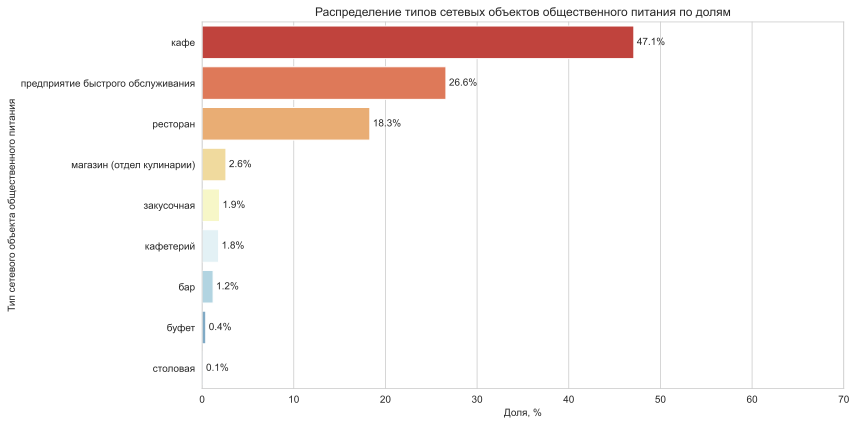

In [19]:
# создадим столбчатую диаграмму распределения типов объектов общественного питания по долям
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=chainornottype, y='object_type', x='chain_object_only_percent', palette='RdYlBu')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Распределение типов сетевых объектов общественного питания по долям', fontsize=12)
plt.ylabel('Тип сетевого объекта общественного питания')
plt.xlabel('Доля, %')
plt.xlim(right=70)
plt.tight_layout()
plt.show()

**Вывод:** по результатам подсчёта данных мы можем говорить о сложившейся тройке лидеров в сетевом распространении объектов общественного опитания: `предприятия быстрого обслуживания` (41,5%), `магазины` (отделы кулинарии) (28,6%) и `рестораны` (23,8%). Минимальное распространение в качестве сетевых единиц общепита имеют `столовые`, `буфеты` и `бары`.

<a id=3.4.></a>
### 3.4. Что характерно для сетевых заведений: много заведений с небольшим числом посадочных мест в каждом или мало заведений с большим количеством посадочных мест?

In [20]:
# чтобы выяснить характерные особенности сетевых объектов общественного питания в контексте количества посадочных мест,
# отфильтруем исходный массив данных и выберем оттуда для работы только сетевые объекты общественного питания
dfchain = df.query('chain == True')

In [21]:
# расчёты значений количества посадочных мест всех типов объектов питания
dfchain.describe().round(1)

,id,number
count,2964.0,2964.0
mean,118096.5,56.1
std,67521.1,55.4
min,838.0,1.0
25%,59187.0,20.0
50%,129967.5,40.0
75%,176803.5,75.0
max,223318.0,580.0


In [22]:
# расчёт медианного значения количества посадочных мест для всей Москвы
print('Медиана количества посадочных мест для сетевых ООП:', int(dfchain['number'].median()), 'мест.')

Медиана количества посадочных мест для сетевых ООП: 40 мест.


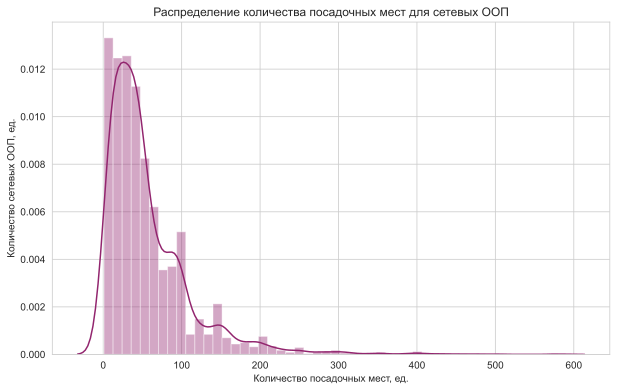

<Figure size 1200x600 with 0 Axes>

In [23]:
# создадим график плотности распределения количества посадочных мест для сетевых ООП 
sns.distplot(dfchain['number'], bins = 50, color = '#92256E').set(ylabel = 'Количество сетевых ООП, ед.', 
                                                                  xlabel = 'Количество посадочных мест, ед.', 
                                                                  title = 'Распределение количества посадочных мест для сетевых ООП')
plt.figure(figsize = (12, 6))
plt.show()

Более подробный визуальный анализ графика плотности распределения количества посадочных мест объектов общественного питания говорит нам о том, что абсолтное большинство средних значений находится в пределах от 1 до 210 посадочных мест. После отметки в 210 линия плотности постоянно убывает. Установим фильт на отметке <= 210 и рассмотрим график более детально.

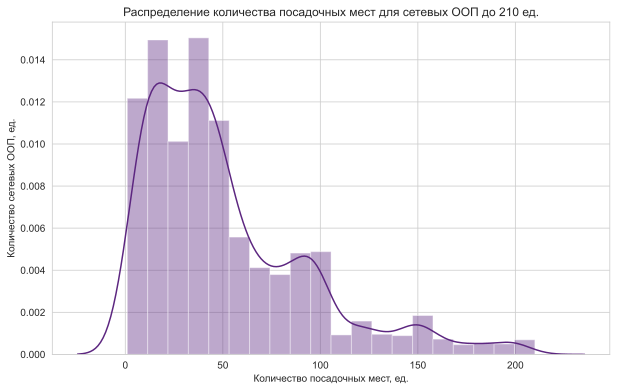

<Figure size 1200x600 with 0 Axes>

In [24]:
# создадим график плотности распределения количества посадочных мест для сетевых ООП 
# создадим массив данных, отфильтрованный по количеству посадочных мест <= 210
dfchain1 = dfchain.query('number <= 210')

sns.distplot(dfchain1['number'], bins = 20, color = '#5C2680').set(ylabel = 'Количество сетевых ООП, ед.', 
                                                                  xlabel = 'Количество посадочных мест, ед.', 
                                                                  title = 'Распределение количества посадочных мест для сетевых ООП до 210 ед.')
plt.figure(figsize = (12, 6))
plt.show()

In [25]:
# Определим границы интервалов и их описания
bins = [
    (0, 20, 'до 20 мест'),
    (20, 50, 'от 20 до 50'),
    (50, 110, 'от 50 до 110'),
    (110, 150, 'от 110 до 150'),
    (150, float('inf'), 'более 150')
]

total = len(dfchain1)
print('Доли сетевых объектов общественного питания по количеству посадочных мест:\n')

for low, high, label in bins:
    if high == float('inf'):
        count = dfchain1.query(f'number >= {low}')['number'].count()
    else:
        count = dfchain1.query(f'number >= {low} and number < {high}')['number'].count()
    share = count / total
    print(f"{label:15} — {share:.1%}")

Доли сетевых объектов общественного питания по количеству посадочных мест:

до 20 мест      — 22.6%
от 20 до 50     — 38.7%
от 50 до 110    — 29.3%
от 110 до 150   — 4.5%
более 150       — 4.8%


**Вывод:** на основании данных описательного анализа мы можем сделать вывод о характерных признаках для сетевых объектов общественного питания на территории города Москва, представленных в количестве 2964 единиц:

* 580 мест - максимальное количество посадочных мест в сетевых ООП
* 1 место - минимальное количество посадочных мест в сетевых ООП
* 55 мест - среднее количество посадочных мест в сетевых ООП

Также мы можем утверждать, что для сетевых объектов общественного питания характерно **малое количество сетевых объектов с большим количеством посадочных мест**.

Таких сетевых объектов общественного питания всего 4,8% (более 150 мест) и 4,5% (от 110 до 150 мест) соответственно из числа всех сетевых объектов общественного питания города Москва.

<a id=3.5.></a>
### 3.5. Для каждого типа объекта общественного питания найти среднее количество посадочных мест. Какой тип предоставляет в среднем самое большое количество посадочных мест? Построить графики.

In [26]:
# рассчитаем среднее количество посадочных мест для каждого ООП
a = df.groupby('object_type').agg({'number':'mean'}).round(0).sort_values(by='number', ascending=False).reset_index()
a

,object_type,number
0,столовая,131.0
1,ресторан,99.0
2,буфет,58.0
3,бар,45.0
4,кафе,42.0
5,предприятие быстрого обслуживания,33.0
6,закусочная,16.0
7,кафетерий,13.0
8,магазин (отдел кулинарии),12.0


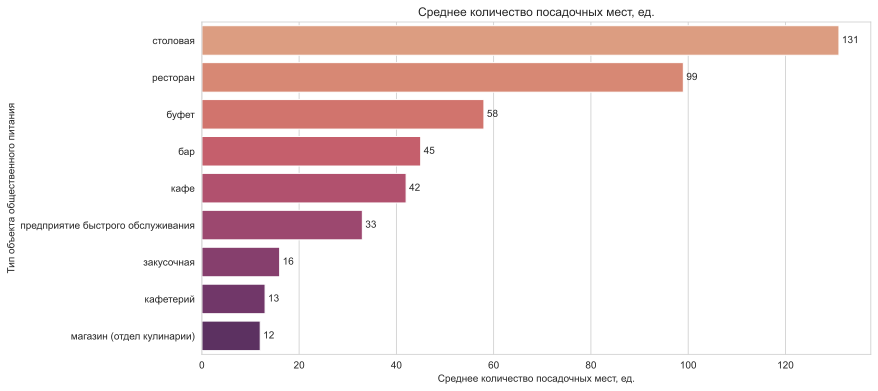

In [27]:
# создадим столбчатую диаграмму рейтинга ООП по количеству посадочных мест
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=a, x='number', y='object_type', alpha=1, palette='flare')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Среднее количество посадочных мест, ед.', fontsize=12)
plt.xlabel('Среднее количество посадочных мест, ед.')
plt.ylabel('Тип объекта общественного питания')
plt.show()

**Вывод:** наибольшее среднее количество посадочных мест является характерным признаком для столовых (131 место) и ресторанов (99 мест). Условное второе место средних значений количества посадочных мест между собой делят буфеты (57 мест), бары (45 мест), кафе (42 места). Низшие позиции занимают предприятия быстрого обслуживания (28 мест), закусочные (12 мест), кафетерий (12 мест), магазин (отдел кулинарии) (9 мест). Между первой и второй, и между второй и третьей условными группами существует значительный разрыв в показателях, который составляет от 42 до 14 единиц.

Ступени прироста среднего количества посадочных мест являются прямым следствием особенностей организации общественного питания, присущих конкретному типу объекта: ассортимент реализуемой кулинарной продукции, кондитерских и булочных изделий, их разнообразие и сложность изготовления; техническая оснащённость (материальная база, инженерно-техническое оснащение и оборудование, состав помещений, архитектурно-планировочные решения и т.д.); методы и формы обслуживания; время обслуживания потребителей (время ожидания, предоставления и потребления услуги); профессиональная подготовка и уровень квалификации персонала; условия обслуживания (комфортность зала, мебели, этика персонала, эстетика оформления, интерьер и т.д.).

Иными словами, среднее количество посадочных мест это своего рода эквивалент времени, которое потребитель услуги может с комфортом провести на базе конкретного объекта общественного питания. Минимальное среднее количество посадочных мест характерно для объектов, работающих в формате "еда на вынос" и быстрого обслуживания посетителя с учётом выбора уже готовых блюд. Максимальное среднее количество посадочных мест относится к столовым, которые в своей деятельности ориентированы на определённый контингент потребителей (школьные, студенческие, офисные, служебные, при больницах, санаториях, домах отдыха и пр.). Рестораны по праву являются золотой серединой между столовыми по своему охвату потребителей и другими типами объектов общественного питания. Именно рестораны с широким ассортиментом блюд сложного изготовления, в том числе шефскими фирменными блюдами и изделиями, алкогольными, прохладительными, горячими и другими видами напитков, кондитерскими и табчными изделиями, с высоким уровнем обслуживания и, как правило, в сочетании с организацией отдыха и развлечений, являются примером сбалансированного сочетания разных видов досуга, и потому пользуются высоким спросом у потребителей.

<a id=3.6.></a>
### 3.6. Выделить в отдельный столбец информацию об улице из столбца `address`.

In [28]:
# создадим список с ключевыми словами для извлечения улицы из полного адреса объекта
streets_names = ['аллея', 'бульвар', 'вал', 'Зеленоград', 'город Московский', 'город Троицк', 
                 'квартал', 'километр', 'линия', 'микрорайон', 'набережная', 'переулок', 
                 'площадь', 'поселение', 'посёлок', 'проезд', 'просек', 'проспект', 
                 'территория', 'тупик', 'ул', 'улица', 'шоссе']

In [29]:
# создадим функцию для извлечения названия улицы из полного адреса объекта
def get_street(address):
    for position in [0,1,2]: # Список возможных позиций слова "улица" в полном названии адреса 
        for address_part in address.split(',')[position].split(' '): # разделим адрес на фрагменты между запятыми
            if address_part in streets_names:  # для каждорго фрагмента адреса найдём совпадение из списка с ключевыми словами 
                street = address.split(', ')[position] # присваиваем найденное значение переменной 'street'
                return street # возвращаем полученное значение улицы

In [30]:
# создадим новый столбец `street` с названием улицы
# для этого применим ранее созданную функцию get_street к столбцу ['adress'], где хранится полный адрес объекта
df['street'] = df['address'].apply(get_street)
df.head(10)

,id,object_name,chain,object_type,address,number,street
0,151635,СМЕТАНА,False,кафе,"город Москва, улица Егора Абакумова, дом 9",48,улица Егора Абакумова
1,77874,Родник,False,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35,улица Талалихина
2,24309,Кафе «Академия»,False,кафе,"город Москва, Абельмановская улица, дом 6",95,Абельмановская улица
3,21894,ПИЦЦЕТОРИЯ,True,кафе,"город Москва, Абрамцевская улица, дом 1",40,Абрамцевская улица
4,119365,Кафе «Вишневая метель»,False,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50,Абрамцевская улица
5,27429,СТОЛ. ПРИ ГОУ СОШ № 1051,False,столовая,"город Москва, Абрамцевская улица, дом 15, корп...",240,Абрамцевская улица
6,148815,Брусника,True,кафе,"город Москва, переулок Сивцев Вражек, дом 6/2",10,переулок Сивцев Вражек
7,20957,Буфет МТУСИ,False,столовая,"город Москва, Авиамоторная улица, дом 8, строе...",90,Авиамоторная улица
8,20958,КПФ СЕМЬЯ-1,False,столовая,"город Москва, Авиамоторная улица, дом 8, строе...",150,Авиамоторная улица
9,28858,Столовая МТУСИ,False,столовая,"город Москва, Авиамоторная улица, дом 8, строе...",120,Авиамоторная улица


In [31]:
# проверка результатов выделения признака
df['street'].isna().sum()

np.int64(0)

**Вывод:** информация с данными об улице, на которой расположен объект общественного питания, выделена из столбца `adress` в отдельный столбец `street`. Пустых и пропущенных значений нет.

<a id=3.7.></a>
### 3.7. Построить график топ-10 улиц по количеству объектов общественного питания. 

In [32]:
# создадим сводную таблицу с искомыми признаками
top10 = df.groupby('street').agg({'object_name':'count'}).reset_index().sort_values(by='object_name', ascending=False).head(10)
top10

,street,object_name
1358,город Зеленоград,232
1428,проспект Мира,204
1012,Профсоюзная улица,182
695,Ленинградский проспект,172
997,Пресненская набережная,167
416,Варшавское шоссе,164
698,Ленинский проспект,148
1395,поселение Сосенское,138
1425,проспект Вернадского,128
686,Кутузовский проспект,114


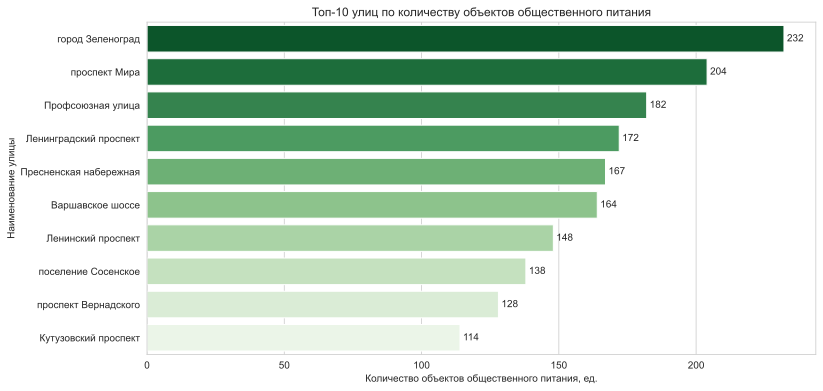

In [33]:
# создадим столбчатую диаграмму топ-10 улиц по количеству объектов общественного питания
plt.figure(figsize=(12, 6))
ax = sns.barplot(data = top10, x='object_name', y='street', alpha=1, palette='Greens_r')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
plt.title('Топ-10 улиц по количеству объектов общественного питания', fontsize=12)
plt.xlabel('Количество объектов общественного питания, ед.')
plt.ylabel('Наименование улицы')
plt.show()

**Вывод:** согласно подсчётам топ-10 улиц города Москвы по количеству объектов общественного питания открывают город Зеленоград (232 ООП) и проспект Мира, где расположены 204 заведения. Также на ведущие позиции претендуют Профсоюзная улица (182 ООП), Ленинградский проспект (172 ООП), Пресненская набережная (167 ООП), Варшавское шоссе (164 ООП). Полагаем возможным отметить, что Варшавское шоссе становится условной линией водораздела между явными лидерами по количеству объектов общественного питания с отрывом в почти 20 единиц. Пятёрку  замыкают Ленинский проспект (148 ООП), поселение Сосенское (138 ООП), проспект Вернадского (128 ООП) и Кутузовский проспект (114 ООП).

<a id=3.8.></a>
### 3.8. Найти число улиц с одним объектом общественного питания.

In [34]:
# рассчитаем число улиц, на которых расположен только один объект общественного питания
len(df.groupby('street').agg({'object_name':'count'}).reset_index().query('object_name == 1'))

548

**Вывод:** число улиц с одним объектом общественного питания составляет 548 единиц.

<a id=3.9.></a>
### 3.9. Рассмотреть распределение количества посадочных мест для улиц с большим количеством объектов общественного питания. Какие закономерности можно выявить?

In [35]:
# создадим список улиц с топ-10 объектов общественного питания 
top10_list = [] # список с названиями улиц
top10 = top10.reset_index()
for x in range(10):
    street = top10.iloc[x]['street']
    top10_list.append(street)

In [36]:
# создадим датафрейм, в котором будут записи только для топ-10 улиц с наибольшим количеством объектов питания
top10df = df.query('street in @top10_list')

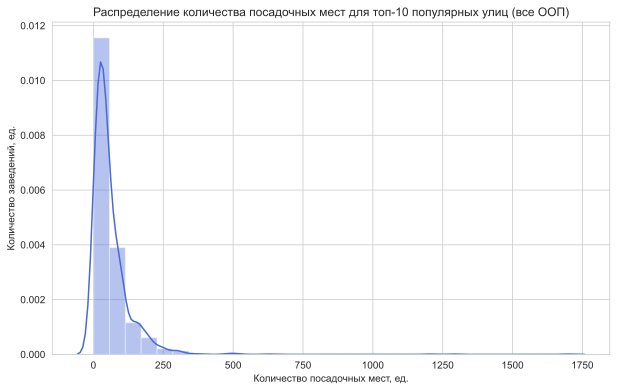

<Figure size 1200x600 with 0 Axes>

In [37]:
# создадим график плотности распределения количества посадочных мест для улиц с топ-10 количеством объектов общественного питания 
sns.distplot(top10df['number'], bins=30, color='#4869D6').\
set(ylabel='Количество заведений, ед.', xlabel='Количество посадочных мест, ед.', 
    title='Распределение количества посадочных мест для топ-10 популярных улиц (все ООП)')
plt.figure(figsize=(12, 6))
plt.show()

Ранее на этапе реализации шага №1 мы говорили о размахе количества посадочных мест. В контексте топ-10 улиц с наибольшим количеством объектов общественного питания, а это 1649 записей, были выделены 3 условные группы, которые последовательно охватывают диапазон значений от 350 до 1700 посадочных мест. По количественному признаку к этим группам "тяжеловесов" относятся 84 объекта общественного питания, которые представляют собой только лишь 0,5% от всего массива данных. Полагаем целесообразным установить фильт данных по количеству посадочных мест, равный 349 и по актуальному усреднённому массиву данных ещё раз построить диаграмму распределения количества посадочных мест для топ-10 улиц по их количеству.

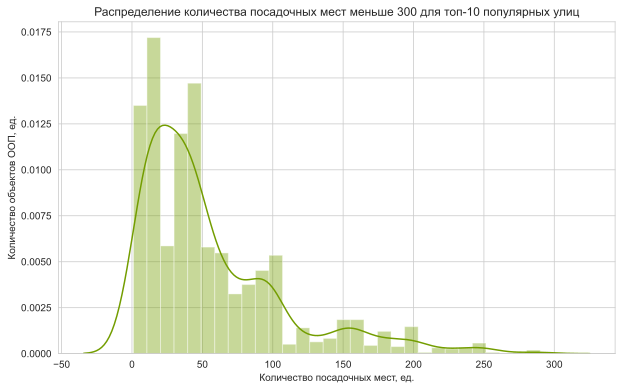

<Figure size 1200x600 with 0 Axes>

In [38]:
# создадим график плотности распределения количества посадочных мест для улиц с топ-10 количеством объектов общественного питания 
# создадим массив данных, отфильтрованный по количеству посадочных мест < 300
actual_top10df = top10df.query('number < 300')

sns.distplot(actual_top10df['number'], bins = 30, color = '#739D00').set(ylabel = 'Количество объектов ООП, ед.', 
                                                                  xlabel = 'Количество посадочных мест, ед.', 
                                                                  title = 'Распределение количества посадочных мест меньше 300 для топ-10 популярных улиц')
plt.figure(figsize = (12, 6))
plt.show()

In [39]:
# расчёты значений количества посадочных мест для топ-10 улиц с наибольшим количеством объектов питания
actual_top10df.describe().round(1)

,id,number
count,1630.0,1630.0
mean,124520.4,55.5
std,72359.2,51.6
min,19650.0,1.0
25%,29406.5,20.0
50%,148903.5,40.0
75%,188497.0,80.0
max,223439.0,290.0


In [40]:
# расчёт медианного значения количества посадочных мест для топ-10 улиц с наибольшим количеством объектов питания
print('Медиана количества посадочных мест для топ-10 наиболее популярных улиц:', int(top10df['number'].median()), 'мест.')

Медиана количества посадочных мест для топ-10 наиболее популярных улиц: 40 мест.


In [41]:
# расчёт медианного значения количества посадочных мест для всей Москвы
print('Медиана количества посадочных мест для всей Москвы:', int(df['number'].median()), 'мест.')

Медиана количества посадочных мест для всей Москвы: 40 мест.


In [42]:
# задаём границы интервалов (bins)
bins = [0, 20, 50, 110, 250, float('inf')]

# задаём подписи для каждого интервала
labels = ['до 20 мест', 'от 20 до 50', 'от 50 до 110', 'от 110 до 250', 'более 250']

# создаём категориальную переменную на основе количества посадочных мест
top10df['seats_category'] = pd.cut(
    top10df['number'],
    bins=bins,
    labels=labels,
    include_lowest=True,   # включает левую границу первого интервала (0)
    right=False            # интервалы вида [a, b), а не (a, b]
)

# вычисляем доли для каждой категории
shares = top10df['seats_category'].value_counts(normalize=True).reindex(labels)

# выводим результат
print('Доли объектов общественного питания на топ-10 улицах по количеству посадочных мест:\n')
for label, share in shares.items():
    print(f"{label:15} — {share:.1%}")

Доли объектов общественного питания на топ-10 улицах по количеству посадочных мест:

до 20 мест      — 23.6%
от 20 до 50     — 36.6%
от 50 до 110    — 26.9%
от 110 до 250   — 10.9%
более 250       — 2.0%


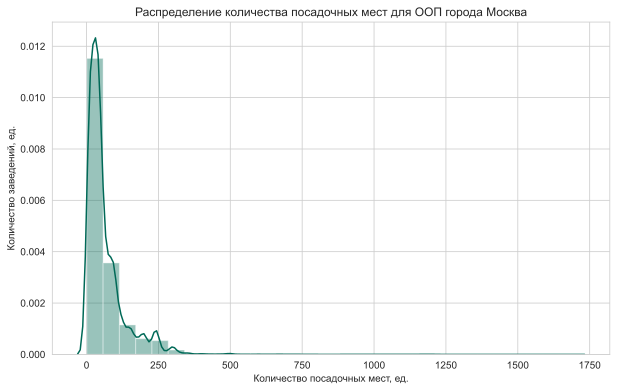

<Figure size 1200x600 with 0 Axes>

In [43]:
# создадим график плотности распределения количества посадочных мест для объектов общественного питания по Москве 
sns.distplot(df['number'], bins=30, color='#006957').\
set(ylabel='Количество заведений, ед.', xlabel='Количество посадочных мест, ед.', title='Распределение количества посадочных мест для ООП города Москва')
plt.figure(figsize=(12, 6))
plt.show()

**Вывод:** по итогам изучения распределения количества посадочных мест для топ-10 улиц с большим количеством объектов общественного питания мы можем наблюдать следующие закономерности.

В среднем количество посадочных мест для всех типов объектов общественного питания составляет 55 мест, при этом аналогичный показатель по городу значительно выше - 63 места. Медианное значение и минимальное значение этого показателя для топ-10 улиц, и для всего города Москва идентично, и составляет 40 мест и 1 место соответственно.

Максимальное количество посадочных мест для топ-10 улиц составляет 290 единиц, по всему городу значение резко возрастает за счёт объектов-гигантов до 1700 единиц.

Даже без дополнительных построений и визуализации очевидным является факт, что наиболее устойчивые в своём существовании объекты общественного питания обладают залами с количеством посадочных мест от 20 до 50 (36,6%), от 50 до 110 (26,9%), до 20 мест (23,6%), от 110 до 250 посадочных мест (10,9%). Более 250 посадочных мест характерно только для 2%  объектов общественного питания на топ-10 улицах Москвы по их количеству.

Полагаем важным отметить, что `порог в 250 посадочных мест является условной линией водораздела между` сложившимся костяком стабильных `сетевых и несетвых объектов общественного питания`, и объектами общественного питания, стремящимися к максимально возможному покрытию по количеству посадочных мест в ущерб усточивости в современных экономических условиях. Так, из 7 объектов-гигантов в настоящее время 3 прекратили свою деятельность, а 1 объект - Арена Сохо - пошла на увеличение своих показателей с 1700 до 2500 посадочных мест.

<a id=4></a>
## Шаг 4. Проверка гипотез о равенстве количества посадочных мест в заведениях сетевого и несетевого типа.

Для проверки гипотезы используем метод математической статистики `p-критерий` — вероятность получить для данной вероятностной модели распределения значений случайной величины такое же или более экстремальное значение статистики, по сравнению с ранее наблюдаемым, при условии, что нулевая гипотеза верна. В качестве нулевой гипотезы установим равенство количества посадочных мест в объектах общественного питания сетевого и несетевого типа. 

Если в результате вычислений значение p-value будет меньше критически значимого уровня, то выдвигаемая нами гипотеза отвергнута и равенство количества посадочных мест в заведениях сетевого и несетевого типа статистически значимо.

Если же в результате вычислений значение p-value будет больше критически значимого уровня, то выдвигаемая нами гипотеза не отвергнута и равенство количества посадочных мест в заведениях сетевого и несетевого типа не имеет статистического значения.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : количество посадочных мест в заведениях сетевого типа} = \text{количество посадочных мест в заведениях несетевого типа}
   \\
   \text{H}_1 \text{ : количество посадочных мест в заведениях сетевого типа} \neq \text{количество посадочных мест в заведениях несетевого типа}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [44]:
# группируем данные по типу объекта и принадлежности к сети
summary = (df.groupby(['chain', 'object_type'])['number'].sum().reset_index())

In [45]:
# переименуем метки для легенды
summary['chain_label'] = summary['chain'].map({True: 'Сетевые', False: 'Несетевые'})

In [46]:
# сортируем по типу объекта
summary = summary.sort_values('object_type')

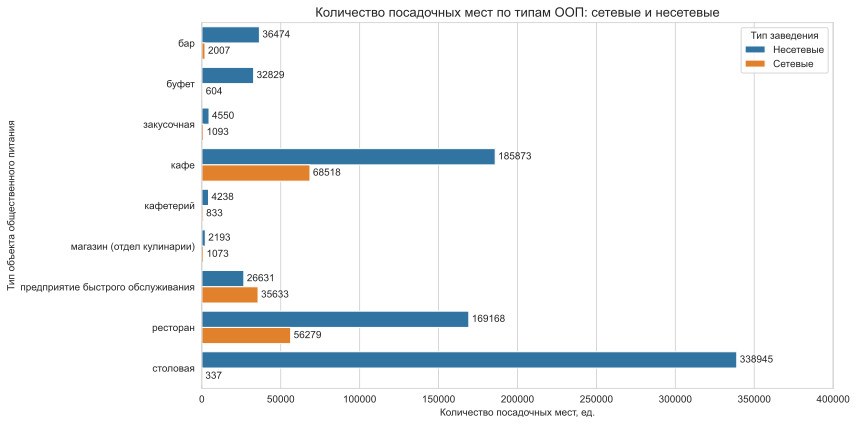

In [47]:
# горизонтальный график с группировкой по `chain_label`
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=summary, y='object_type', x='number', hue='chain_label', palette={'Сетевые': '#FF7F0E', 'Несетевые': '#1F77B4'}, dodge=True)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Количество посадочных мест по типам ООП: сетевые и несетевые', fontsize=13)
plt.xlabel('Количество посадочных мест, ед.')
plt.ylabel('Тип объекта общественного питания')
plt.legend(title='Тип заведения')
plt.xlim(right=400000)
plt.tight_layout()
plt.show()

In [48]:
# установим критически значимый уровень alpha равный 0,05
alpha = 0.05

# с помощью метода математической статистики определяем p-value
results = stats.ttest_ind(df[df['chain'] == True]['number'], df[df['chain'] == False]['number'])
('p-value: {}'.format(results.pvalue))

'p-value: 2.7295513198536213e-09'

**Вывод:** в результате вычислений значение p-value равно 2.7295513198536213e-09, это число больше критически значимого уровня alpha 0.05. Следовательно, выдвигаемая нами гипотеза не отвергнута и равенство количества посадочных мест в заведениях сетевого и несетевого типа не имеет статистического значения. 

<a id=5></a>
## Шаг 5. Рекомендации по открытию нового объекта общественного питания

Общественное питание является самостоятельной отраслью экономики, состоящей из предприятий различных форм собственности и организационно-управленческой структуры, организующей питание населения, а также производство и реализацию готовой продукции и полуфабрикатов, как на предприятии общественного питания, так и вне его, с возможностью оказания широкого перечня услуг по организации досуга и других дополнительных услуг.

В целях регулирования сферы общественного питания разработаны и действуют ряд нормативных правовых документов межгосударственного, федерального и локального уровней:
* ГОСТ 30389-2013. Межгосударственный стандарт. Услуги общественного питания. Предприятия общественного питания. Классификация и общие требования.
* ГОСТ 31985-2013. Межгосударственный стандарт. Услуги общественного питания. Термины и определения.
* ГОСТ Р 50762-2007. Национальный стандарт Российской Федерации. Услуги общественного питания. Классификация предприятий общественного питания.
* МГСН 4.14-98. Московские городские строительные нормы. Предприятия общественного питания.

Приведённый перечень документов является основополагающим для подготовки рекомендаций по вопросу потенциального открытия нового заведения общественного питания на территории города Москва.

По итогам анализа исходного массива данных, мы можем сформировать некоторые рекомендации по вопросу потенциального открытия нового заведения общественного питания на территории города Москва.

<a id=5></a>
### Шаг 5.1. Тип объекта общественного питания

Самым широко представленным типом объекта общественного питания является кафе (39,7%). Едва ли столовые (16,9%) и рестораны (14,9%) с соответствующими показателями могут навязать борьбу за лидирующие позиции в данном аспекте. Численное превосходство кафе говорит о популярности этого типа у потребителей, а также явно свидетельствует о наибольшей финансовой устойчивости и жизнеспособности развития данного объекта в долгосрочной перспективе.

Стоит также отметить, что сетевой характер распространения кафе на территории города Москвы носят только 23% объектов этого типа.

Кафе — это предприятие общественного питания по организации питания и (или без) отдыха потребителей с предоставлением ограниченного по сравнению с рестораном ассортимента продукции общественного питания, реализующее фирменные, заказные блюда, изделия и алкогольные и безалкогольные напитки.

|Вид кафе|Основные направления деятельности|
|:---|:---|
| `по ассортименту реализуемой продукции` | неспециализированные и специализированные (кафе-мороженое, кафе-кондитерская, кафе-молочная, кафе-пиццерия, молодёжное кафе и др.|
| `по обслуживаемому контингенту и интересам потребителей, включая оформление интерьера` | молодёжное, детское, студенческое, офисное, кафе-клуб, интернет-кафе, арт-кафе, кафе-кабачок и др. |
| `по местонахождению` | в жилых и общественных зданиях, в том числе в отдельно стоящих зданиях, зданиях гостиниц, вокзалов; в культурно-развлекательных и спортивных объектах; в зонах отдыха |
| `по методам и формам обслуживания` | с обслуживанием официантами и с самообслуживанием |
| `по времени функционирования` | постоянно действующие и сезонные |
| `по составу и назначению помещений` | стационарные и передвижные (автокафе, вагон-кафе, кафе на морских и речных судах и т.п.) |

Разнообразие видов кафе как объекта общественного питания даёт возможность широкого выбора и максимальной адаптации к условиям социума и среды.

<a id=5.2.></a>
### Шаг 5.2. Количество посадочных мест

Московские городские строительные нормы от 14.04.1998 года (далее — МГСН 4.14-98) устанавливают строительные и потребительские требования к зданиям и помещениям предприятий, оказывающих услуги общественного питания, в том числе требования к размещению, функциональным группам, составу и площадям помещений, объёмно-планировочным решениям, внутренней среде и инженерному оборудованию зданий массовых типов предприятий питания.

В п.3.2. части 3 МГСН 4.14-98 приведены оптимальные величины количества мест в зале общедоступных предприятий питания, в том числе кафе:

|Тип кафе|Количество посадочных мест в зале, ед.|
|:---|:---|
| `Кафе общего типа` | 50 - 200 |
| `Кафе специализированное` | 25 - 100 |

Согласно результатам анализа имеющего массива данных, среднее количество посадочных мест в кафе составляет 42 места. Эти данные подтверждаются срезом по количеству посадочных мест на топ-10 улицах Москвы, имеющих наибольшее количество объектов общественного питания. Суммарно доля ООП от 20 до 50 посадочных мест составляет 60,2% рынка.

Таким образом, мы можем рекомендовать проектное число в диапазоне от 20 до 50 посадочных мест.

<a id=5.3.></a>
### Шаг 5.3. Место расположения

В результате исследования исходного массива данных мы получили перечень топ-10 улиц города Москвы по количеству объектов общественного питания:

|Наименование улицы города Москвы|Количество объектов общественного питания, ед.|
|:---|:---|
| `город Зеленоград` | 232 |
| `проспект Мира` | 204 |
| `Профсоюзная улица` | 182 |
| `Ленинградский проспект` | 172 |
| `Пресненская набережная` | 167 |
| `Варшавское шоссе` | 164 |
| `Ленинский проспект` | 148 |
| `поселение Сосенское` | 138 |
| `проспект Вернадского` | 128 |
| `Кутузовский проспект` | 114 |

Безусловно, стоит ориентироваться на этот перечень лидеров при изучении перспективы создания нового объекта общественного питания. Однако, в условиях динамичного роста и развития города Москвы, расширения и улучшения инфраструктуры города, стоит уделить внимание и новым перспективным районам, где уровень конкуренции чрезвычайно мал, а спрос потребителей на данный вид услуг высокий.

В части 3 МГСН 4.14-98 приведены требования к размещению объектов общественного питания, при этом необходимо руководствоваться перспективными схемами развития генеральных планов районов с учётом как нового строительства, так и реконструкции действующих предприятий с возможным изменением их специализации, исходя из инвестиционных предпочтений заказчиков. 

Кафе целесообразно разместить в общественных и торговых центрах, на магистралях и площадях, вблизи остановок городского транспорта, станций метрополитена, вокзалов и аналогичных местах оживлённого движения населения, а также на рекреационных территориях. 

Кафе как предприятие питания повседневного обслуживания вместимостью, как правило, от 25 до 75 мест следует ориентировать на приближённое обслуживание и размещать на территории жилых (муниципальных) районов с учётом обслуживания работников предприятий и учреждений, размещаемых на этих территориях.

Неочевидным, но очень существенным фактором при выборе места дислокации потенциального объекта обзественного питания, является стоимость аренды квадратного метра помещения. Место размещения находится в зависимости от бюджета проекта учредителя и подтверждённых намерений инвесторов в содействии. Следует искать оптимальное соотношение по количеству объектов со стоимостью аренды квадратного метра в том случае, когда бюджет ограничен. В случае, если стоимость аренды квадратного метра является вторичным условием, то во главу угла ставится большой клиентопоток.

<a id=5.4.></a>
### Шаг 5.4. Проведение дополнительных исследований

Вышеперечисленные рекомендации требуют существенного дополнения актуальными данными в части:

- определение арендной ставки из расчёта на один кв.м для объекта общественного питания на соответствующей улице города Москвы;

- проведение исследований и замера трафика пешеходов, посетителей аналогичных объектов общественного питания, потока городского общественного транспорта. Метод визуального статистического наблюдения позволяет фиксировать интенсивность и структуру потоков пешеходов на улице или трафик посетителей внутри торговых центов. Считаем проведение данного исследования значимым перед открытием нового объекта общественного питания. Замеры проходимости для повышения эффективности потенциального объекта общественного питания необходимы для разработки корректного графика работы и количества персонала, также необходимо сравнение проходящего и посетительского трафика с конкурентами. Замер транспортных потоков является чрезвычайно актуальным для объектов общественного питания, поскольку входная группа, информационные вывески, рекламные носители видны потенциальным посетителям с проезжей части. Реализация всего комплекса этих исследований позволит эффективнее управлять движением посетителей и учитывать трафик в виде коэффициентов к базовой ставке аренды;

- перечень учреждений (медицинских, образовательных, культурных, спортивных), организаций, заводов, предприятий, достопримечательностей, иных объектов массового притяжения жителей и гостей города Москвы;

- учёт сложившихся туристических маршрутов;

- выявить потенциально притягательные для размещения здания (высотки, объекты культурного наследия, топовые отели, гостиницы).

<a id=5.5.></a>
### Шаг 5.5. Выводы по рекомендациям

На основании вышеизложенного, учредителю рекомендуется рассмотреть возможность открытия нового объекта общественного питания типа несетевого кафе с количеством посадочных мест от 20 до 50, расположенным на следующих улицах города Москвы, указанных в порядке убывания приоритетности: город Зеленоград, проспект Мира, Профсоюзная улица, Ленинградский проспект, Пресненская набережная, Варшавское шоссе, Ленинский проспект, поселение Сосенское, проспект Вернадского, Кутузовский проспект. Проведение дополнительных исследований, указанных в предыдущем пункте исследования, будет способствовать формированию более детальной дорожной карты проекта,  поможет выявить потенциальные риски и угрозы на предпроектной стадии, что в свою очередь, окажет положительное влияние на благополучие учредителя и потенциальных потребителях услуг объектов общественного питания.